## Exploratory Data Analysis

In [9]:
# Import Libraries

import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading Data

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

### Filter for US Data Analyst roles

In [2]:
df_DA_US = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

In [7]:
df_plot=df_DA_US['job_location'].value_counts().head(10).to_frame()

df_plot

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


### Lets plot using seaborn

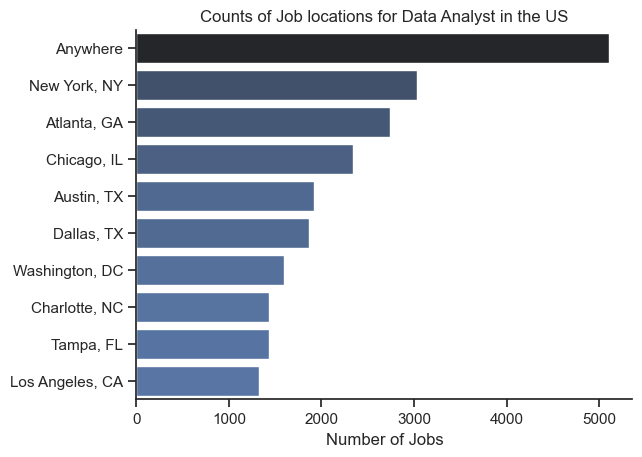

In [17]:
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r',
  legend=False)
sns.despine() #to remove borders
sns.set_theme(style='ticks')

plt.title('Counts of Job locations for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

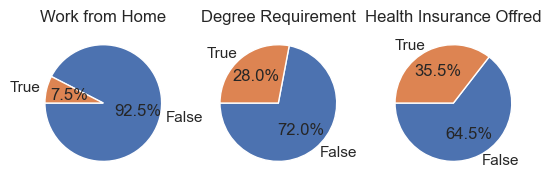

In [21]:
fig, ax=plt.subplots(1,3)

dict_column={
  'job_work_from_home':'Work from Home',
  'job_no_degree_mention':'Degree Requirement',
  'job_health_insurance':'Health Insurance Offred' 
}

for i, (column, title) in enumerate(dict_column.items()):
  ax[i].pie(df_DA_US[column].value_counts(), startangle=180, autopct='%1.1f%%', labels=['False','True'])
  ax[i].set_title(title)


plt.show()

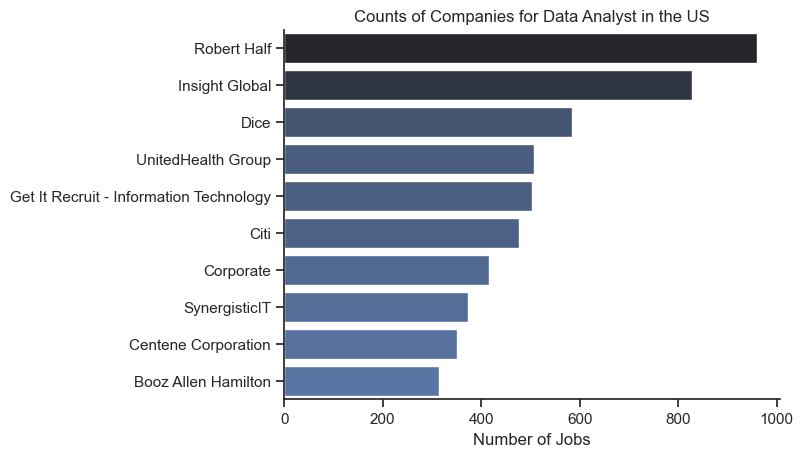

In [22]:
df_plot=df_DA_US['company_name'].value_counts().head(10).to_frame()


sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r',
  legend=False)
sns.despine() #to remove borders
sns.set_theme(style='ticks')

plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()